SubAgents: A deep agent can create subagents to delegate work.You can specify custom subagents parameter. Subagents are useful for context quarantine(keeping the main agent context clean) and providing speacialized instrcutions. This page covers synchronous subagents where the supervisor blocks untill the subagents finishes. For long running tasks, pareller workstreams, or cases where you need mid-flight streering and cacellation, see Async agents

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

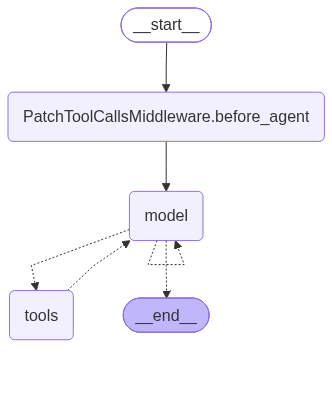

In [17]:
from typing import Literal
from tavily import TavilyClient

from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.getenv('TAVILY_API_KEY'))

def internet_search(
    query:str,
    max_results:int=5,
    topic: Literal["general","news","finance",]="general",
    include_raw_content: bool=False
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

research_subagent = {
    "name": "research-subagent",
    "description": (
        "Use this subagent proactively for requests requiring "
        "in-depth internet research, fact-finding, or a detailed "
        "technical report. It searches the web using Tavily and "
        "returns a structured summary with sources."
    ),
    "system_prompt": (
        "You are a research specialist. Use the internet_search tool "
        "to investigate the assigned topic. Gather relevant evidence, "
        "compare findings where useful, and return a detailed, "
        "well-structured report with source URLs."
    ),
    "tools": [internet_search],
    "model": "openai:gpt-5.4",
}

agent = create_deep_agent(
    model="openai:gpt-5.5",
    subagents=[research_subagent],
    system_prompt=(
        "You are the main assistant. For requests requiring "
        "in-depth internet research, delegate the research task "
        "to the research-subagent using the task tool. "
        "After receiving its report, summarize the findings "
        "for the user. Do not claim to have delegated unless "
        "you actually called the subagent."
    ),
)
agent

In [18]:
result = agent.invoke(
    {
        "messages":[{
            "role":"user", "content":"Research about LLM Gateways and provide a detailed summary."
        }],
    },
    config={"configurable":{"thread_id":"subagent-demo1"}},
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about LLM Gateways and provide a detailed summary.
================================== Ai Message ==================================

[{'id': 'rs_0a27c81e746e3565006ac0f0a44ae487d28cdf8fd2a5501038', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqwPCmMoZBXMPU7cCNFdEpDo8-H6utqAt-kkxB9FkcGi3hvTf7vA0P9zOPAu_oolE9si3YCvQW1BGhIUUCNmC_A9tH4sHeNUSY1CIDaStKRO1R0H6D3QV0aiWWCPzXsDHq6azylYAn7zZoNWYGa7ITiAeJw6Q4kp3IaXAB5EloEfyT-Sa11vSwsEMjVO7pziytPLDVJsXR7CJENYfDiRFuEJy7YxT8Ej8ThoYhZjj7F-z1w6CwdtmIvsgvJXKOMqNPk5_QlO1Y7Go24nzcW_4hbSHn5sQAX_SUMUD26AaRVfyRv9cTd61t2klSonUcX9BMmazJMaJLSC25-sL0DucBjJv7OdE7L6NwXpW81GZp-r3-5fgr5dV1CYsZj6t0VsO63isVQG9l6u6f5CUHTcPD-h8ryy__OxoPVWCOamnPxhQBdHQnMxeNDpvPBU1F9Nb5Ss4O8L4H4OuzIoND3nZ0OvdGaMNlJEnV-5s4TBf0DU8btXN4cgBDSxjSTrXyXHBlxzk4S51UEEGP5sFwmjnD_I6a6dkb0jZb-T0OYYy1B6rJW5VdJ4BJU2puYniqE7FaVTTHJB15vJBPK7JbnDglm2K0go6wEf9IffRXraVEHhx9-eB1PvXNZx

In [23]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent


class ResearchFindings(BaseModel):
    """Structured findings from a research task."""

    summary: str = Field(
        description="Summary of findings"
    )
    confidence: float = Field(
        description="Confidence score from 0 to 1"
    )
    sources: list[str] = Field(
        description="List of source URLs"
    )


research_subagent = {
    "name": "researcher",
    "description": (
        "Conducts in-depth internet research on a topic using "
        "the internet_search tool and returns structured findings "
        "with a summary, confidence score, and source URLs."
    ),
    "system_prompt": (
        "Research the assigned topic thoroughly using the "
        "internet_search tool. Base your summary on the findings, "
        "include relevant source URLs, and provide a confidence "
        "score between 0 and 1."
    ),
    "tools": [internet_search],
    "response_format": ResearchFindings,  # Correct key
}

agent = create_deep_agent(
    model="openai:gpt-5.5",
    subagents=[research_subagent],
    system_prompt=(
        "You are the main research assistant. For requests involving "
        "research or recent developments, delegate the research to "
        "the researcher subagent using the task tool. Use its findings "
        "to formulate your final answer."
    ),
)

result = await agent.ainvoke({
    "messages": [{
        "role": "user",
        "content": (
            "Research recent advances in quantum computing. "
            "Delegate the research to the researcher subagent."
        )
    }]
})

for message in result["messages"]:
    print("\n", type(message).__name__)
    print("Content:", message.content)

    if getattr(message, "tool_calls", None):
        print("Tool calls:", message.tool_calls)


 HumanMessage
Content: Research recent advances in quantum computing. Delegate the research to the researcher subagent.

 AIMessage
Content: [{'arguments': '{"description":"Research recent advances in quantum computing, focusing on developments from roughly 2024 to present. Cover hardware milestones (superconducting, trapped-ion, neutral atom, photonic, silicon/spin), quantum error correction and logical qubits, algorithms/applications, benchmarks/roadmaps, and notable industry/academic announcements. Return a structured report with: (1) concise executive summary, (2) key advances with dates and organizations, (3) implications and remaining challenges, (4) source URLs. Include confidence assessment and note any areas where claims are preliminary or marketing-heavy.","subagent_type":"researcher"}', 'call_id': 'call_txRcIDQ7HO9QSYwNThTNyvGl', 'name': 'task', 'type': 'function_call', 'id': 'fc_09253965a3999fa6006ac0f4886b2087d2bd1813871bc3d17d', 'status': 'completed'}]
Tool calls: [{'nam